In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor

blocks = ['fact-ppl', 'fact-nonppl', 'inference-social', 'inference-nonsocial', 'next', 'relation', 'feel']
block_names = {
    'fact-ppl': 'Person-related facts',
    'fact-nonppl': 'Non-person-related facts',
    'inference-social': 'Social inference',
    'inference-nonsocial': 'Non-social inference',
    'next': 'Next event prediction',
    'relation': 'Interpersonal relationship',
    'feel': 'Emotional inference'
}

/Users/me/repos/bio_ann/imageQA/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
img = 'lb000228'
answers = pickle.load(open(f'vipllava_answers.pkl', 'rb'))
images = {img: Image.open(f'/Users/me/repos/bio_ann/imageQA/analysis/images/{img[:-4]}.jpg') for img in answers.keys()}
attn = np.load(f'attns/vipllava_attn_{img}.npz', allow_pickle=True)

for k in attn.keys():
    print(answers[img + '.png'][k]['question'])
    print(answers[img + '.png'][k]['answer'])

What is the man wearing?
The man is wearing a dress shirt, tie, and slacks.</s>
What is this place?
This place is a classroom.</s>
What might people be talking about?
In the image, a man is standing in front of a chalkboard with a green background, and he appears to be talking to a group of students. It is likely that he is a teacher or a guest speaker, and he could be discussing a topic related to the class or the subject matter being taught. The students are seated at desks, and some of them have books on their desks, which suggests that they are engaged in a learning activity. The conversation could be about the material being taught, a recent assignment, or a current event that relates to the class.</s>
What time of the day is it?
It is daytime.</s>
What is going to happen next?
The teacher is going to write on the chalkboard.</s>
What is the relationship between the girls?
The girls are classmates in a classroom.</s>
How is the man feeling about what he says?
The man appears to be

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..1.9998449].


(3, 336, 336)


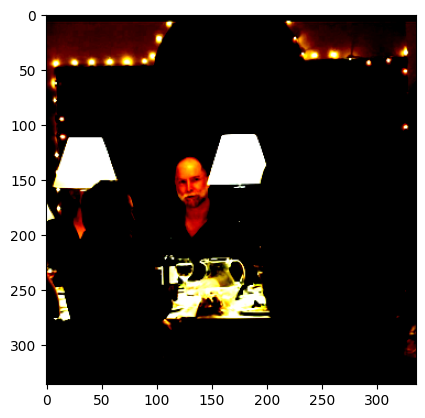

In [ ]:
processor = AutoProcessor.from_pretrained('llava-hf/vip-llava-7b-hf')
arr = processor(text='test',images=images[img+'.png'])['pixel_values'][0]
print(arr.shape)
arr = np.swapaxes(arr, 0, 2)
arr = np.swapaxes(arr, 0, 1)
plt.imshow(arr)

In [7]:
block = 'next'
img_idx = np.where(np.array(answers[f'{img}.png'][block]['input_ids']) == 32000)  # 32000 is the <image> token

txt_start = np.where(np.array(answers[f'{img}.png'][block]['input_ids']) == 13)[0][0] + 1
txt_end = np.where(np.array(answers[f'{img}.png'][block]['input_ids']) == 2277)[0][-1]
assert 612 < txt_start < txt_end
txt_idx = slice(txt_start, txt_end)
processor.decode(np.array(answers[f'{img}.png'][block]['input_ids'])[txt_start:txt_end])

NameError: name 'processor' is not defined

In [ ]:
layer = 20
# i2t_attn = np.mean(np.squeeze(attn[block][layer, :, txt_idx, img_idx]), axis=1)  # average attention from image to all question text tokens
# i2t_attn = np.mean(i2t_attn, axis=1)
i2t_attn = attn[img][block][layer]
print(i2t_attn.shape)
# plt.imshow(arr)
plt.imshow(i2t_attn.reshape(24, 24), vmax=.003)
plt.colorbar()

(32, 24, 24) (24, 24)
(24,)


ValueError: cannot reshape array of size 24 into shape (24,24)

In [11]:
attn[img][block].shape

(32, 24, 24)

In [5]:
attn = pickle.load(open('vipllava_img2txt_attn.pkl', 'rb'))
eyedata = pickle.load(open('eyedata_reformatted4vipllava_raw_fix.pkl', 'rb'))
# eyedata = pickle.load(open('eyedata_aggregated_raw_fix.pkl', 'rb'))

(-0.012, 0.012398083242115693)

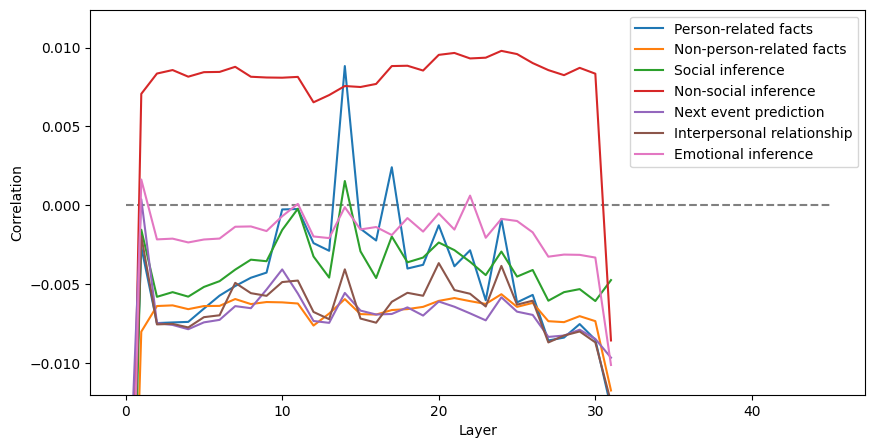

In [6]:
from attn_correlation import correlate_across_data

correlations = correlate_across_data(attn, eyedata, method='pearson')

plt.figure(figsize=(10, 5))
plt.hlines([0.], color='grey', xmin=0, xmax=45, linestyle='--')
for b in blocks:
    plt.plot(np.mean(correlations[b], axis=1), label=block_names[b])
plt.legend()
plt.xlabel('Layer')
plt.ylabel('Correlation')
plt.ylim(bottom=-.012)

Text(0.5, 1.0, '2D Cross Correlation')

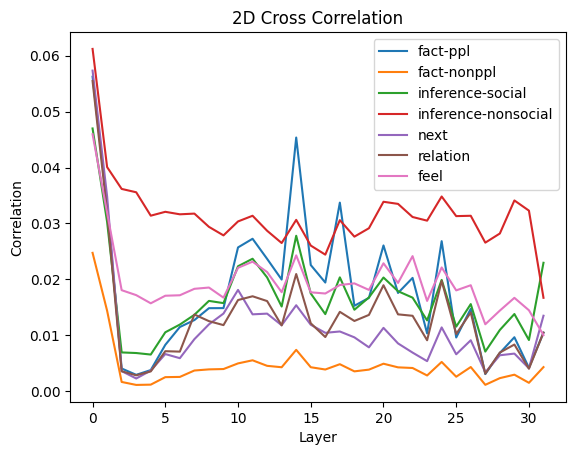

In [ ]:
correlations = correlate_across_data(attn, eyedata, method='2d')
for b in blocks:
    plt.plot(np.mean(correlations[b], axis=1), label=b)
plt.legend()
plt.xlabel('Layer')
plt.ylabel('Correlation')
plt.title('2D Cross Correlation')

/Users/me/repos/bio_ann/imageQA/analysis/attn_correlation.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(data1.flatten(), data2.flatten()).statistic


([<matplotlib.axis.YTick at 0x15c7a6210>,
 [Text(0, 0, 'Person-related facts'),
  Text(0, 1, 'Non-person-related facts'),
  Text(0, 2, 'Social inference'),
  Text(0, 3, 'Non-social inference'),
  Text(0, 4, 'Next event prediction'),
  Text(0, 5, 'Interpersonal relationship'),
  Text(0, 6, 'Emotional inference')])

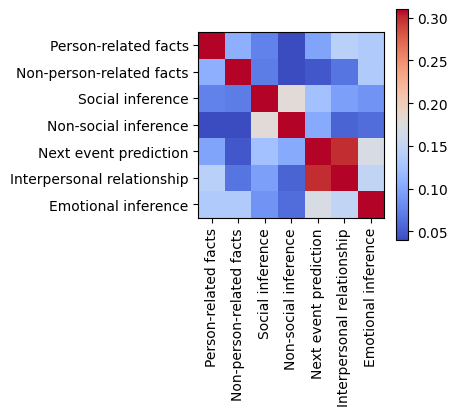

In [46]:
from attn_correlation import correlate_across_condition

eye_correlations = correlate_across_condition(eyedata, method='pearson')
plt.figure(figsize=(3, 3))
plt.imshow(eye_correlations, vmax=.31, cmap='coolwarm')
plt.colorbar()
plt.xticks(np.arange(len(blocks)), [block_names[b] for b in blocks], rotation=90)
plt.yticks(np.arange(len(blocks)), [block_names[b] for b in blocks])

Text(0.5, 1.0, 'Layer 30')

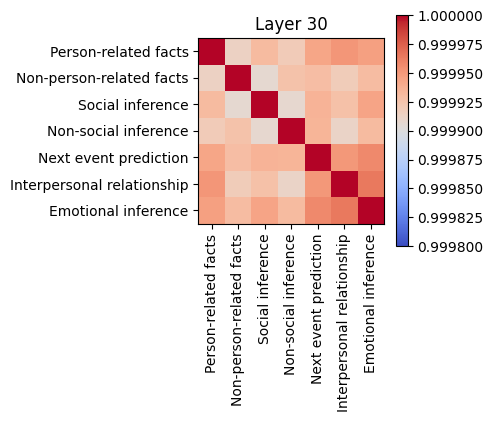

In [ ]:
from attn_correlation import correlate_across_condition

layer = 30  # layer 14 lowest .98, layer 18, 27 changed trend
correlations = correlate_across_condition(attn, method='pearson')
plt.figure(figsize=(3, 3))
plt.imshow(correlations[:,:,layer], vmax=1, vmin=.9998, cmap='coolwarm')
plt.colorbar()
plt.xticks(np.arange(len(blocks)), [block_names[b] for b in blocks], rotation=90)
plt.yticks(np.arange(len(blocks)), [block_names[b] for b in blocks])
plt.title(f'Layer {layer}')

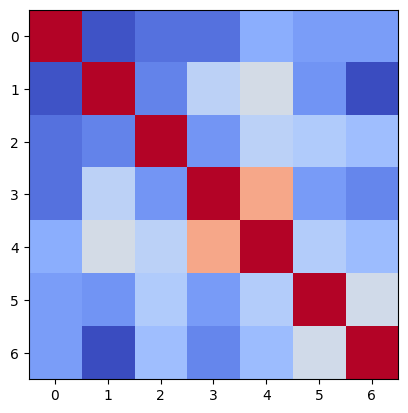

In [21]:
plt.imshow(np.mean(correlations[:,:,18:27], axis=2), vmax=1, cmap='coolwarm')
# plt.imshow(np.mean(correlations[:,:,27:31], axis=2), vmax=1, cmap='coolwarm')

Text(0, 0.5, 'Spearman correlation')

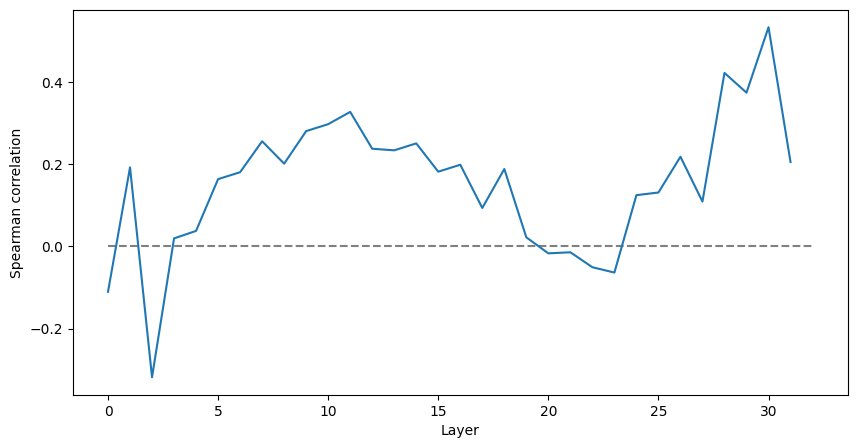

In [42]:
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, pearsonr

plt.figure(figsize=(10, 5))
# plt.vlines([2, 11, 23, 30], ymin=-.2, ymax=.4, color='grey', linestyle='--')
plt.hlines([0.], color='grey', xmin=0, xmax=32, linestyle='--')
corrs = []
for layer in range(32):
    r = spearmanr(squareform(correlations[:,:,layer], checks=False), squareform(eye_correlations, checks=False)).statistic
    corrs.append(r)
plt.plot(corrs)
plt.xlabel('Layer')
plt.ylabel('Spearman correlation')

AttributeError: 'dict' object has no attribute 'shape'